# Factors Associated with Time Until Adoption in Animal Shelters

### CSCI 3022 Final Project

*Using data from the Austin Animal Center (Austin, Texas, USA)*

**Aleksandra Trubitsyna**  
Applied Mathematics, University of Colorado Boulder  
Instructor: Dr. Osita Eluemuno Onyejekwe  
July 2026  

## Introduction

Animal shelters provide temporary care for homeless, abandoned, and surrendered animals while working to find permanent homes through adoption. Understanding which factors are associated with the time required for an animal to be adopted can help shelters allocate resources, improve adoption strategies, and ultimately support animal welfare.

This project analyzes [intake](https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Intakes-10-01-2013-to-05-05-2/wter-evkm/about_data) and [outcome](https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Outcomes/9t4d-g238) records from the Austin Animal Center to investigate factors associated with **time until adoption**. After cleaning and merging the intake and outcome datasets, the analysis focuses exclusively on *adopted dogs and cats*.  

Exploratory data analysis is used to examine adoption patterns across animal characteristics such as species, age, and breed, as well as intake month, while statistical analysis, including nonparametric hypothesis testing and bootstrap resampling, is used to evaluate and quantify these relationships. Finally, a predictive model is created in order to investigate whether time until adoption can be predicted given the factors described above. 

## Import Libraries

In [2714]:
# General
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

# Predictive Modeling
from sklearn.model_selection import train_test_split
import sklearn.linear_model as lm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Data

In [2716]:
# Load intake and outcome datasets
intakes = pd.read_csv('intakes.csv')
outcomes = pd.read_csv('outcomes.csv')

In [2717]:
# Inspect dataset dimensions
print(f"Intakes shape = {intakes.shape},\nOutcomes shape = {outcomes.shape}.")

Intakes shape = (173812, 12),
Outcomes shape = (173775, 12).


In [2718]:
# Display column names
print(f"Intakes columns: {intakes.columns},\nOutcomes columns: {outcomes.columns}.")

Intakes columns: Index(['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Found Location',
       'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake',
       'Age upon Intake', 'Breed', 'Color'],
      dtype='object'),
Outcomes columns: Index(['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear',
       'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome',
       'Age upon Outcome', 'Breed', 'Color'],
      dtype='object').


In [2719]:
# Check duplicate animal IDs
print("Duplicate Animal IDs in Intakes:", intakes["Animal ID"].duplicated().sum())
print("Duplicate Animal IDs in Outcomes:", outcomes["Animal ID"].duplicated().sum())
print("\nUnique Animal IDs in Intakes:", intakes["Animal ID"].nunique())
print("Unique Animal IDs in Outcomes:", outcomes["Animal ID"].nunique())

Duplicate Animal IDs in Intakes: 17525
Duplicate Animal IDs in Outcomes: 17538

Unique Animal IDs in Intakes: 156287
Unique Animal IDs in Outcomes: 156237


## Data Cleaning

In [2721]:
# Remove animals that appear more than once 
intakes_clean = intakes.drop_duplicates(subset="Animal ID", keep=False)
outcomes_clean = outcomes.drop_duplicates(subset="Animal ID", keep=False)

In [2722]:
# Merge datasets (only keep animals that appear in both datasets)
shelter_data = intakes_clean.merge(outcomes_clean, on="Animal ID", how="inner")

In [2723]:
# Verify the merged dataset
print(f"Merged dataset size: {len(shelter_data):,}")
print(f"Duplicate Animal IDs: {shelter_data['Animal ID'].duplicated().sum()}")
print(f"Unique Animal IDs: {shelter_data['Animal ID'].nunique():,}")

Merged dataset size: 141,844
Duplicate Animal IDs: 0
Unique Animal IDs: 141,844


In [2724]:
# Analyze duplicate columns
column_differences = {
    "Name": (shelter_data["Name_x"] != shelter_data["Name_y"]).sum(),
    "Breed": (shelter_data["Breed_x"] != shelter_data["Breed_y"]).sum(),
    "Color": (shelter_data["Color_x"] != shelter_data["Color_y"]).sum(),
    "Animal Type": (shelter_data["Animal Type_x"] != shelter_data["Animal Type_y"]).sum(),
    "Sex": (shelter_data["Sex upon Intake"] != shelter_data["Sex upon Outcome"]).sum()
}

for column_name, diff in column_differences.items():
    print(f'Different entries in "{column_name}": {diff}')

Different entries in "Name": 48820
Different entries in "Breed": 0
Different entries in "Color": 0
Different entries in "Animal Type": 0
Different entries in "Sex": 62391


In [2725]:
# Remove redundant columns after merging
shelter_data = shelter_data.drop(columns=[
    "Name_x",
    "Name_y",
    "Breed_y",
    "Color_y",
    "Animal Type_y",
    "MonthYear_x",
    "MonthYear_y"
])

In [2726]:
# Rename the columns using snake_case format
shelter_data = shelter_data.rename(columns={
    "Animal ID": "animal_id",
    "DateTime_x": "intake_datetime",
    "DateTime_y": "outcome_datetime",
    "Date of Birth": "date_of_birth",
    "Animal Type_x": "animal_type",
    "Breed_x": "breed",
    "Color_x": "color",
    "Intake Type": "intake_type",
    "Intake Condition": "intake_condition",
    "Sex upon Intake": "sex_intake",
    "Sex upon Outcome": "sex_outcome",
    "Age upon Intake": "age_intake",
    "Age upon Outcome": "age_outcome",
    "Outcome Type": "outcome_type",
    "Outcome Subtype": "outcome_subtype"
})

In [2727]:
# Inspect the distribution of animal types
shelter_data["animal_type"].value_counts()

animal_type
Dog          69025
Cat          63041
Other         8868
Bird           877
Livestock       33
Name: count, dtype: int64

In [2728]:
# Filter the dataset to adopted dogs and cats
shelter_data = shelter_data[shelter_data["animal_type"].isin(["Dog", "Cat"])].copy()
shelter_data = shelter_data[shelter_data["outcome_type"] == "Adoption"].copy()

## Feature Engineering

In [2730]:
# Convert date columns to datetime format
shelter_data["intake_datetime"] = pd.to_datetime(shelter_data["intake_datetime"])
shelter_data["outcome_datetime"] = pd.to_datetime(shelter_data["outcome_datetime"],format="mixed")
shelter_data["date_of_birth"] = pd.to_datetime(shelter_data["date_of_birth"])

/var/folders/k2/gf3t3pvn6gg8b795gtt814tw0000gn/T/ipykernel_31737/3469500372.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  shelter_data["outcome_datetime"] = pd.to_datetime(shelter_data["outcome_datetime"],format="mixed")


In [2731]:
# Remove timezone information from outcome datetimes
shelter_data["outcome_datetime"] = shelter_data["outcome_datetime"].apply(
    lambda x: x.replace(tzinfo=None) if x.tzinfo is not None else x)

In [2732]:
# Convert back to datetime64
shelter_data["outcome_datetime"] = pd.to_datetime(shelter_data["outcome_datetime"])

In [2733]:
# Create 'length of stay' column
shelter_data["length_of_stay"] = (shelter_data["outcome_datetime"]- shelter_data["intake_datetime"])
shelter_data["length_of_stay_days"] = (shelter_data["length_of_stay"].dt.total_seconds() / (24 * 60 * 60))

# Convert to integer
shelter_data["length_of_stay_days"] = np.floor(shelter_data["length_of_stay_days"]).astype(int)

LOS = "length_of_stay_days"

shelter_data[LOS].describe()

count    64832.000000
mean        34.781558
std         59.287281
min         -1.000000
25%          5.000000
50%         15.000000
75%         44.000000
max       1912.000000
Name: length_of_stay_days, dtype: float64

In [2734]:
# Analyse 'length of stay' column
print("Negative stays:", (shelter_data[LOS] < 0).sum())
print("Missing stays:", shelter_data[LOS].isna().sum())

Negative stays: 4
Missing stays: 0


In [2735]:
# Replace negative shelter stays with zero days
shelter_data.loc[shelter_data[LOS] < 0,LOS] = 0

In [2736]:
# Verify negative stays
print("Negative stays:", (shelter_data[LOS] < 0).sum())

Negative stays: 0


In [2737]:
# Replace invalid negative ages with missing values
shelter_data.loc[shelter_data["age_intake"].str.startswith("-"),"age_intake"] = np.nan

In [2738]:
# Convert age strings to numeric years
def age_to_years(age):
    if pd.isna(age):
        return np.nan

    number, unit = age.split()
    number = float(number)

    if "day" in unit:
        return number / 365.25
    elif "week" in unit:
        return number * 7 / 365.25
    elif "month" in unit:
        return number / 12
    elif "year" in unit:
        return number

    return np.nan

shelter_data["age_years"] = shelter_data["age_intake"].apply(age_to_years)

In [2739]:
# Create intake month variable using intake date
shelter_data["intake_month"] = shelter_data["intake_datetime"].dt.month

## Distribution of Time Until Adoption

Before investigating factors associated with adoption time, the overall distribution of the response
variable was examined. Summary statistics, histograms, and boxplots were used to understand the
distribution of shelter length of stay among adopted animals.

In [2741]:
# Compute statistics for shelter length of stay
print(f"Median: {shelter_data[LOS].median():.2f}")
print(f"Skewness: {shelter_data[LOS].skew():.2f}")

iqr = (shelter_data[LOS].quantile(0.75)-shelter_data[LOS].quantile(0.25))
print(f"IQR: {iqr:.2f}")

Median: 15.00
Skewness: 7.32
IQR: 39.00


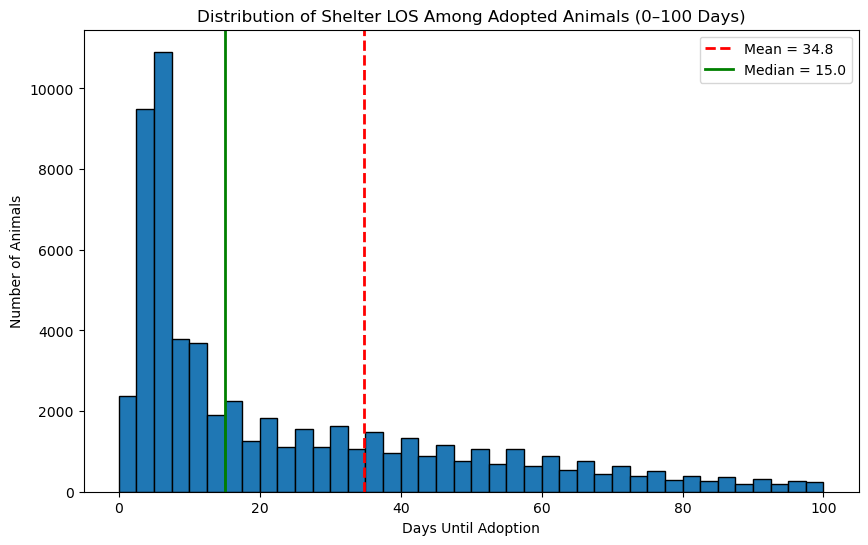

In [2742]:
# Plot the distribution of shelter length of stay
plt.figure(figsize=(10,6))

plt.hist(shelter_data[LOS],
         bins=40,
         range=(0,100),
         edgecolor="black")

plt.axvline(shelter_data[LOS].mean(),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean = {shelter_data[LOS].mean():.1f}")

plt.axvline(shelter_data[LOS].median(),
            color="green",
            linewidth=2,
            label=f"Median = {shelter_data[LOS].median():.1f}")

plt.title("Distribution of Shelter LOS Among Adopted Animals (0–100 Days)")
plt.xlabel("Days Until Adoption")
plt.ylabel("Number of Animals")
plt.legend()

plt.show()

**Figure 1. Distribution of shelter length of stay among adopted animals.** The histogram displays shelter stays up to 100 days to improve visualization of the distribution, while the calculated mean and median are based on the complete dataset.

## Dogs VS. Cats

Animal type was first investigated to determine whether dogs and cats exhibited different times until
adoption.

In [2745]:
# Display the distribution of dogs and cats
print(shelter_data["animal_type"].value_counts())
print(f"Dataset size: {len(shelter_data):,}")

animal_type
Dog    33541
Cat    31291
Name: count, dtype: int64
Dataset size: 64,832


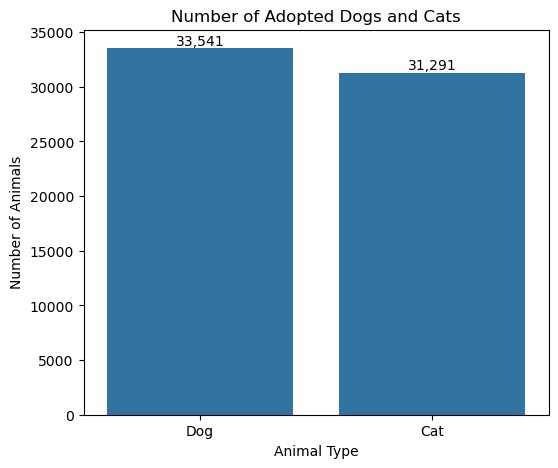

In [2746]:
# Plot the distribution of adopted dogs and cats
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=shelter_data, x="animal_type")

# Display counts above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

plt.title("Number of Adopted Dogs and Cats")
plt.xlabel("Animal Type")
plt.ylabel("Number of Animals")

plt.show()

**Figure 2. Number of adopted dogs and cats in the analysis dataset.** The dataset contains 33,541 dogs (51.7%) and 31,291 cats (48.3%), providing balanced sample sizes for comparisons between the two animal types.

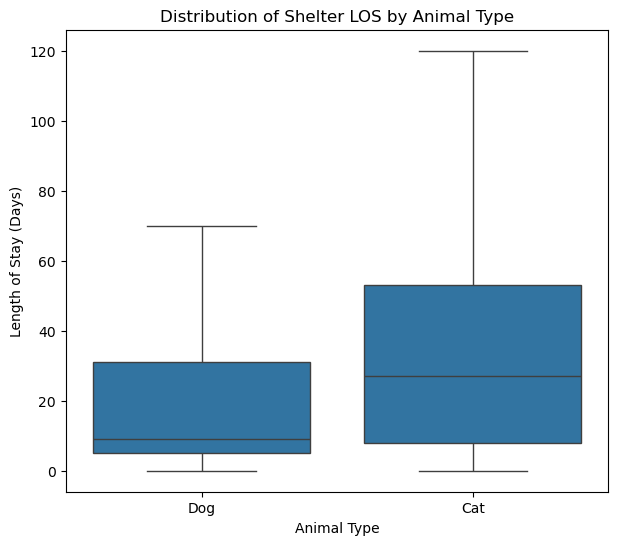

In [2748]:
# Compare shelter length of stay by animal type
plt.figure(figsize=(7, 6))

sns.boxplot(
    data=shelter_data,
    x="animal_type",
    y=LOS,
    showfliers=False
)

plt.title("Distribution of Shelter LOS by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Length of Stay (Days)")

plt.show()

**Figure 3. Distribution of shelter length of stay by animal type.** The outliers were removed to improve visualization. Boxplots summarize the median, interquartile range, and overall spread of shelter stays for dogs and cats. 

### Mann–Whitney U Test

To determine whether the observed differences in shelter length of stay between dogs and cats were statistically significant, a Mann–Whitney U test was performed.

**Hypotheses**

- **Null hypothesis ($H_0$):** The distribution of shelter length of stay is the same for dogs and cats.
- **Alternative hypothesis ($H_A$):** The distribution of shelter length of stay differs between dogs and cats.

In [2751]:
dogs = shelter_data.loc[shelter_data["animal_type"] == "Dog",LOS]
cats = shelter_data.loc[shelter_data["animal_type"] == "Cat",LOS]
u_stat, p_value = mannwhitneyu(dogs,cats,alternative="two-sided")

print(f"U statistic: {u_stat:,.0f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

U statistic: 380,684,991
P-value: < 0.001


**Interpretation**

The Mann–Whitney U test produced a test statistic of U = 380,684,991 with **p < 0.001**. Therefore, the null hypothesis was rejected, indicating a statistically significant difference in shelter length of stay between dogs and cats.

### Bootstrapping

Bootstrap resampling was used to estimate the difference in median shelter length of stay.

In [2754]:
# Separate adoption times
dog_los = shelter_data.loc[shelter_data["animal_type"] == "Dog",LOS].values
cat_los = shelter_data.loc[shelter_data["animal_type"] == "Cat",LOS].values

# Observed difference in medians (Cat - Dog)
observed_diff = np.median(cat_los) - np.median(dog_los)

# Bootstrap
n_boot = 10000
boot_diffs = np.empty(n_boot)

rng = np.random.default_rng(42)

for i in range(n_boot):
    dog_sample = rng.choice(dog_los, size=len(dog_los), replace=True)
    cat_sample = rng.choice(cat_los, size=len(cat_los), replace=True)

    boot_diffs[i] = np.median(cat_sample) - np.median(dog_sample)

# 95% confidence interval
lower, upper = np.percentile(boot_diffs, [2.5, 97.5])

print(f"Observed median difference: {observed_diff:.2f} days")
print(f"95% CI: ({lower:.2f}, {upper:.2f})")

Observed median difference: 18.00 days
95% CI: (18.00, 19.00)


**Interpretation**

A bootstrap analysis with 10,000 resamples estimated the difference in median adoption time between cats and dogs. The observed difference was 18 days, with a 95% bootstrap confidence interval of 18–19 days. 

## Shelter Length of Stay by Age Group

The relationship between age and shelter length of stay was next investigated to determine whether adoption time differed across age groups. Animals were classified into five age categories: under 6 months, 6–12 months, 1–3 years, 3–7 years, and 7 years or older.

In [2757]:
# Group animals into age categories
age_bins = [0, 0.5, 1, 3, 7, float("inf")]

age_labels = [
    "Under 6 months",
    "6–12 months",
    "1–3 years",
    "3–7 years",
    "7+ years"]

shelter_data["age_group"] = pd.cut(
    shelter_data["age_years"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True)

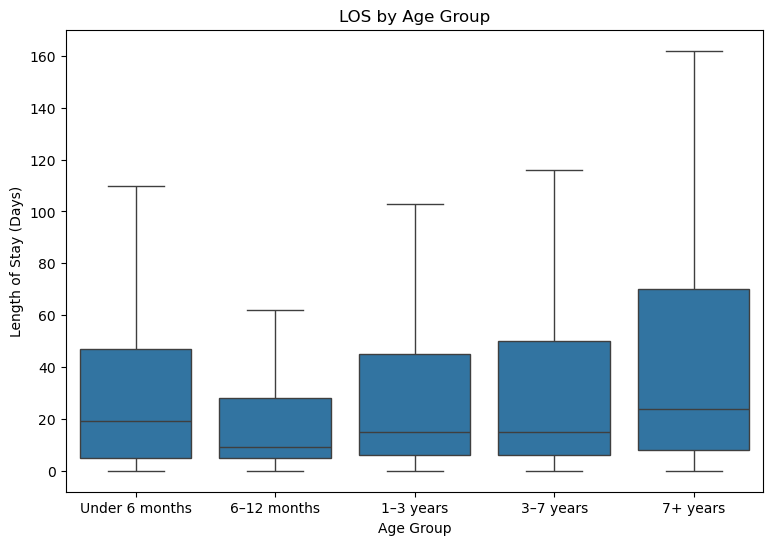

In [2758]:
# Compare shelter length of stay across age groups
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=shelter_data,
    x="age_group",
    y=LOS,
    showfliers=False
)

plt.title("LOS by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Length of Stay (Days)")

plt.show()

**Figure 4. Distribution of shelter length of stay across age groups.** The outliers were removed to improve visualization. Boxplots summarize the distribution of shelter stays for each age category. 

### Kruskal–Wallis Test

To determine whether shelter length of stay differs across age groups, a Kruskal–Wallis H test was performed. This nonparametric test compares the distributions of three or more independent groups without assuming normally distributed data.

**Hypotheses**

- **Null hypothesis ($H_0$):** The distribution of shelter length of stay is the same across all age groups.
- **Alternative hypothesis ($H_A$):** At least one age group differs in its distribution of shelter length of stay.

In [2761]:
groups = [
    shelter_data.loc[shelter_data["age_group"] == group, LOS]
    for group in age_labels
]

H, p_value = kruskal(*groups)

print(f"H statistic: {H:.3f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

H statistic: 833.441
P-value: < 0.001


**Interpretation**

The Kruskal–Wallis test indicated a statistically significant difference in shelter length of stay among the five age groups (H = 833.441, **p < 0.001**). Therefore, the null hypothesis was rejected, suggesting that age is associated with time until adoption.

## Shlter Length of Stay by Breed

Breed was next investigated to determine whether adoption time differed among common breeds. Because dog and cat breeds differ substantially, the analyses were conducted separately for each animal type. To ensure adequate sample sizes, only the most common breeds identified during data preparation were included in the statistical comparisons.

In [2764]:
# Create separate Dogs and Cats DataFrames
dogs = shelter_data[shelter_data["animal_type"] == "Dog"].copy()
cats = shelter_data[shelter_data["animal_type"] == "Cat"].copy()

In [2765]:
# Remove "Mix" from breed names to combine mixed and purebred animals
dogs["breed_clean"] = dogs["breed"].str.replace(" Mix", "", regex=False)
cats["breed_clean"] = cats["breed"].str.replace(" Mix", "", regex=False)

## Dog Breed Analysis

In [2767]:
# Count observations for each cleaned dog breed
dog_breed_counts = dogs["breed_clean"].value_counts()

# Keep only common breeds (at least 500 adopted dogs)
common_dog_breeds = dog_breed_counts[dog_breed_counts >= 250].index

# Create a dataset containing only the common breeds
dogs_common = dogs[dogs["breed_clean"].isin(common_dog_breeds)]

print(f"Number of common dog breeds analyzed: {len(common_dog_breeds)}")
print(f"Minimum observations per breed: 200")

Number of common dog breeds analyzed: 25
Minimum observations per breed: 200


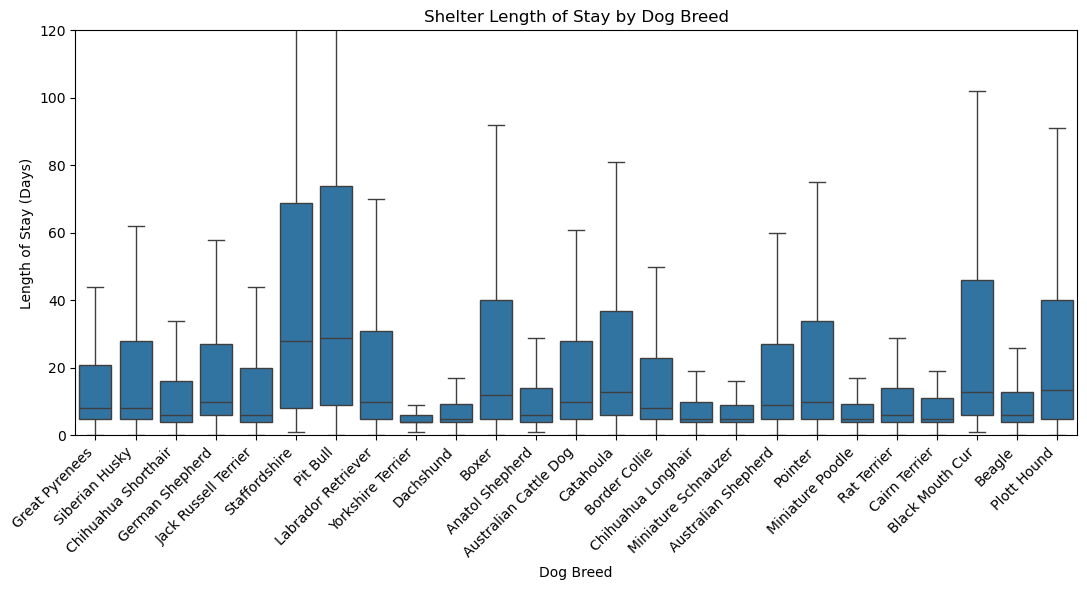

In [2768]:
# Plot the LOS distribution among common dog breeds
plt.figure(figsize=(11,6))

sns.boxplot(
    data=dogs_common,
    x="breed_clean",
    y=LOS,
    showfliers=False
)

plt.ylim(0, 120)


plt.xticks(rotation=45, ha="right")
plt.xlabel("Dog Breed")
plt.ylabel("Length of Stay (Days)")
plt.title("Shelter Length of Stay by Dog Breed")

plt.tight_layout()
plt.show()

**Figure 5. Shelter length of stay by dog breed.** The outliers were removed to improve visualization. Boxplot shows noticeable differences in shelter length of stay among common dog breeds. While the distributions overlap, some breeds exhibit consistently shorter median shelter stays than others, and variability also differs across breeds.

### Kruskal–Wallis Test

To determine whether shelter length of stay differs across common dog breeds, a Kruskal–Wallis H test was performed. This nonparametric test compares the distributions of three or more independent groups without assuming normally distributed data.

**Hypotheses**

- **Null hypothesis ($H_0$):** The distribution of shelter length of stay is the same across all common dog breeds.
- **Alternative hypothesis ($H_A$):** At least one common dog breed differs in its distribution of shelter length of stay.

In [2771]:
groups = [
    dogs_common.loc[
        dogs_common["breed_clean"] == breed,
        LOS
    ]
    for breed in common_dog_breeds
]

H, p = kruskal(*groups)

print(f"H statistic: {H:.3f}")

if p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p:.4f}")

H statistic: 2627.786
P-value: < 0.001


**Interpretation**

The test indicated a statistically significant difference among breeds (H = 2627.786, **p < 0.001**). Therefore, the null hypothesis was rejected, providing evidence that shelter length of stay differs among dog breeds.

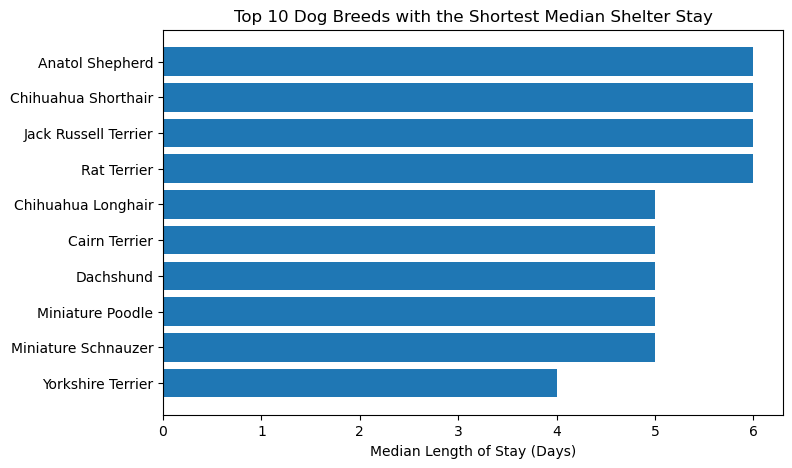

In [2773]:
# Compare median length of stay across common dog breeds
dog_medians = (
    dogs_common
    .groupby("breed_clean")[LOS]
    .median()
    .sort_values()
)

top10_shortest = dog_medians.head(10)

plt.figure(figsize=(8,5))


plt.barh(top10_shortest.index, top10_shortest.values)

plt.xlabel("Median Length of Stay (Days)")
plt.title("Top 10 Dog Breeds with the Shortest Median Shelter Stay")

plt.show()

**Figure 6a. Top 10 dog common breeds with the shortest median shelter stay.** 

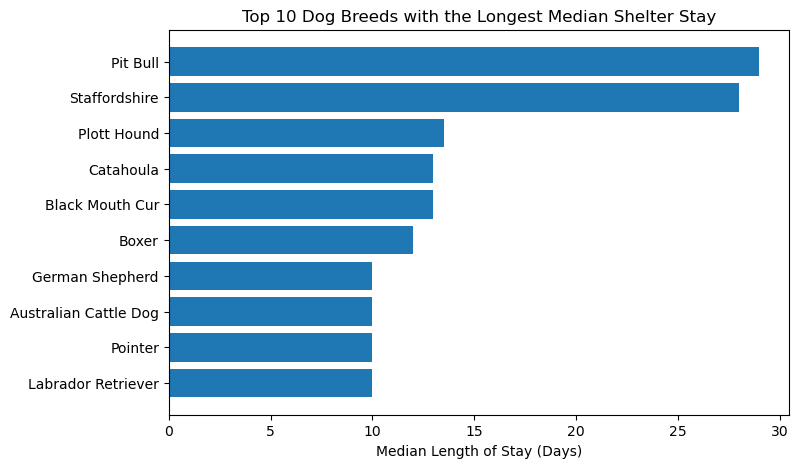

In [2775]:
top10_longest = dog_medians.tail(10).sort_values()

plt.figure(figsize=(8,5))

plt.barh(top10_longest.index, top10_longest.values)

plt.xlabel("Median Length of Stay (Days)")
plt.title("Top 10 Dog Breeds with the Longest Median Shelter Stay")

plt.show()

**Figure 6b. Top 10 common dog breeds with the longest median shelter stay.** 

## Cat Breed Analysis

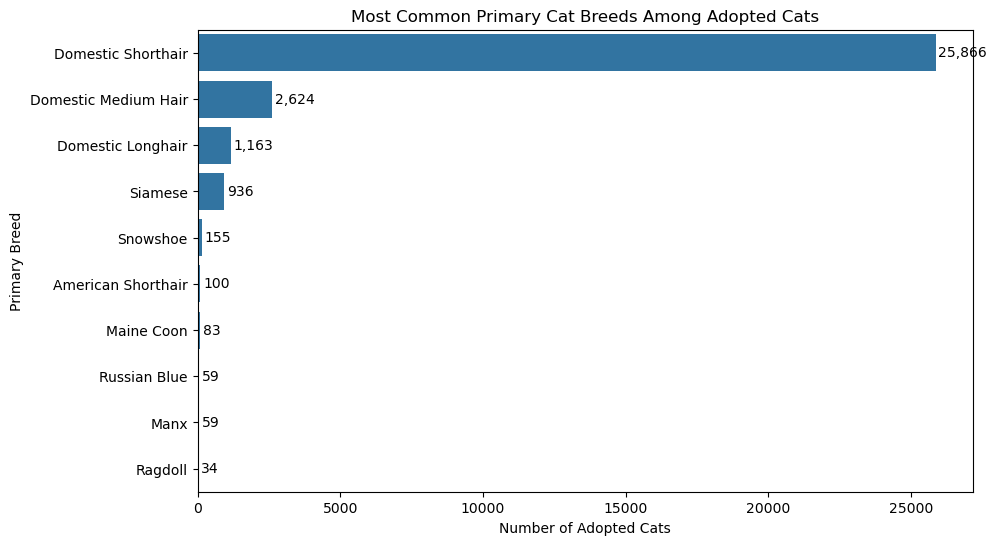

In [2778]:
# Count observations for each cleaned cat breed
cat_breed_counts = cats["breed_clean"].value_counts()

top10_cat = (cats["breed_clean"].value_counts().head(10))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top10_cat.values,
    y=top10_cat.index
)

plt.title("Most Common Primary Cat Breeds Among Adopted Cats")
plt.xlabel("Number of Adopted Cats")
plt.ylabel("Primary Breed")

# Add count labels
for i, v in enumerate(top10_cat.values):
    ax.text(v + 100, i, f"{v:,}", va="center")

plt.show()

**Interpretation**

The adopted cat population is dominated by Domestic Shorthairs (25,866 animals), with substantially fewer observations for all other breeds. Only a handful of breeds contain large enough sample sizes for reliable statistical comparison. Consequently, the breed analysis focuses on the most frequently represented breeds to reduce the influence of very small sample sizes.

In [2780]:
# Keep only common breeds (at least 34 adopted cats)
common_cat_breeds = cat_breed_counts[cat_breed_counts >= 34].index

# Create a dataset containing only the common breeds
cats_common = cats[cats["breed_clean"].isin(common_cat_breeds)]

print(f"Number of common cat breeds analyzed: {len(common_cat_breeds)}")
print(f"Minimum observations per breed: 200")

Number of common cat breeds analyzed: 10
Minimum observations per breed: 200


In [2781]:
analysis_count = cats[cats["breed_clean"].isin(common_cat_breeds)].shape[0]

percentage = analysis_count / len(cats) * 100

print(f"The analyzed breeds represent {percentage:.1f}% of all adopted cats.")

The analyzed breeds represent 99.3% of all adopted cats.


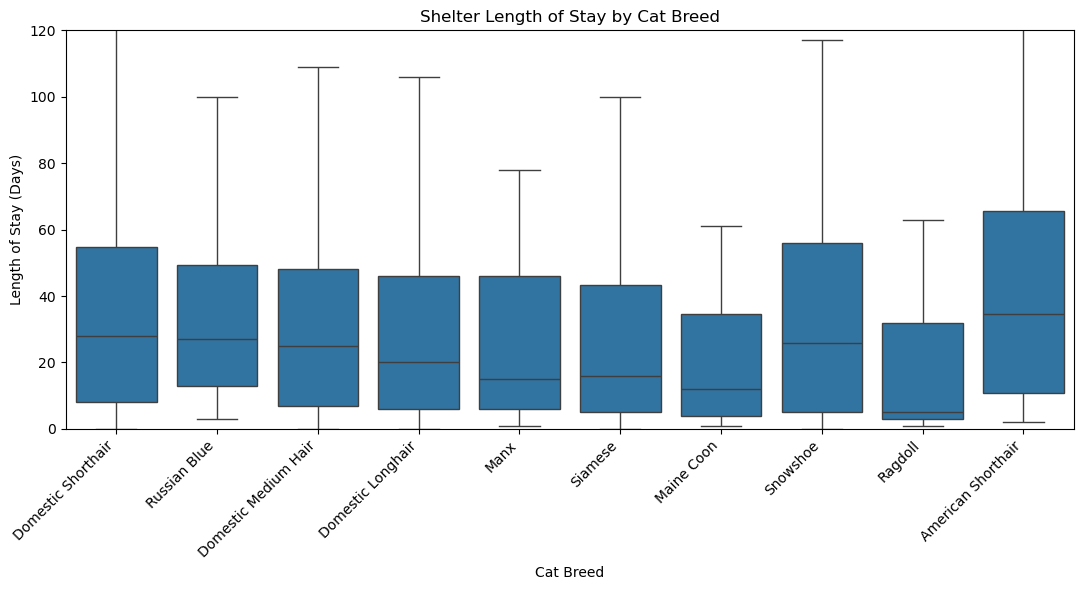

In [2782]:
# Plot the LOS distribution among common cat breeds
plt.figure(figsize=(11,6))

sns.boxplot(
    data=cats_common,
    x="breed_clean",
    y=LOS,
    showfliers=False
)

plt.ylim(0, 120)


plt.xticks(rotation=45, ha="right")
plt.xlabel("Cat Breed")
plt.ylabel("Length of Stay (Days)")
plt.title("Shelter Length of Stay by Cat Breed")

plt.tight_layout()
plt.show()

**Figure 7. Shelter length of stay by cat breed.** The outliers were removed to improve visualization. Although the
distributions overlap considerably, several breeds exhibit noticeably different median shelter stays.

### Kruskal–Wallis Test

To determine whether shelter length of stay differs across common cat breeds, a Kruskal–Wallis H test was performed. This nonparametric test compares the distributions of three or more independent groups without assuming normally distributed data.

**Hypotheses**

- **Null hypothesis ($H_0$):** The distribution of shelter length of stay is the same across all common cat breeds.
- **Alternative hypothesis ($H_A$):** At least one common cat breed differs in its distribution of shelter length of stay.

In [2785]:
groups = [
    cats_common.loc[
        cats_common["breed_clean"] == breed,
        LOS
    ]
    for breed in common_cat_breeds
]

H, p = kruskal(*groups)

print(f"H statistic: {H:.3f}")

if p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p:.4f}")

H statistic: 179.575
P-value: < 0.001


**Interpretation**

The test indicated a statistically significant difference among breeds (H = 179.575, **p < 0.001**). Therefore, the null hypothesis was rejected, providing evidence that shelter length of stay differs among cat breeds.

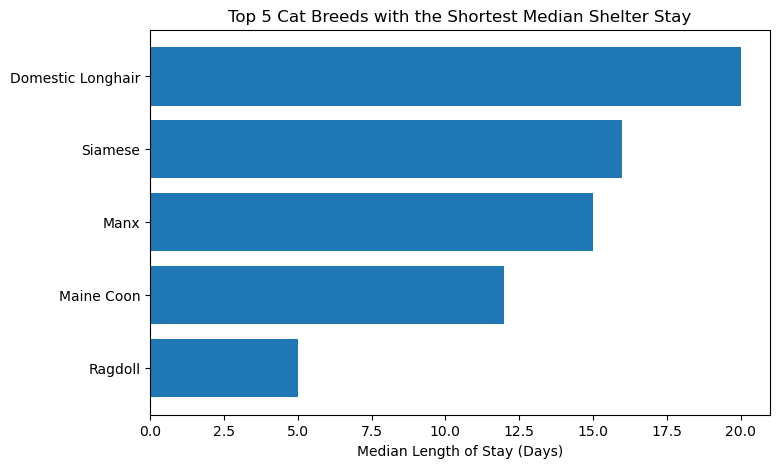

In [2787]:
# Compare median length of stay across common cat breeds
cat_medians = (
    cats_common
    .groupby("breed_clean")[LOS]
    .median()
    .sort_values()
)

top5_shortest = cat_medians.head(5)

plt.figure(figsize=(8,5))


plt.barh(top5_shortest.index, top5_shortest.values)

plt.xlabel("Median Length of Stay (Days)")
plt.title("Top 5 Cat Breeds with the Shortest Median Shelter Stay")

plt.show()

**Figure 8a. Top 5 cat common breeds with the shortest median shelter stay.** 

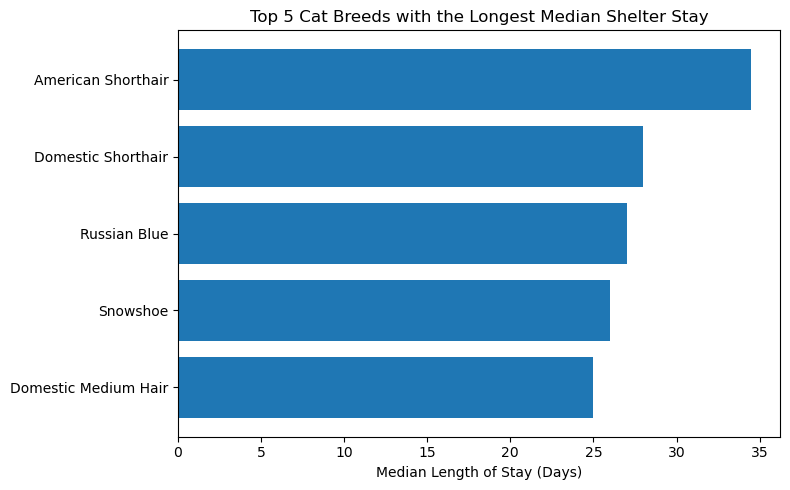

In [2789]:
top5_longest = cat_medians.tail(5).sort_values()

plt.figure(figsize=(8,5))

plt.barh(top5_longest.index, top5_longest.values)

plt.xlabel("Median Length of Stay (Days)")
plt.title("Top 5 Cat Breeds with the Longest Median Shelter Stay")

plt.tight_layout()
plt.show()

**Figure 8b. Top 5 cat common breeds with the longest median shelter stay.** 

## Shelter Length of Stay by Intake Month

The relationship between intake month and shelter length of stay was investigated to determine
whether adoption time varied throughout the year.

/var/folders/k2/gf3t3pvn6gg8b795gtt814tw0000gn/T/ipykernel_31737/2464444980.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


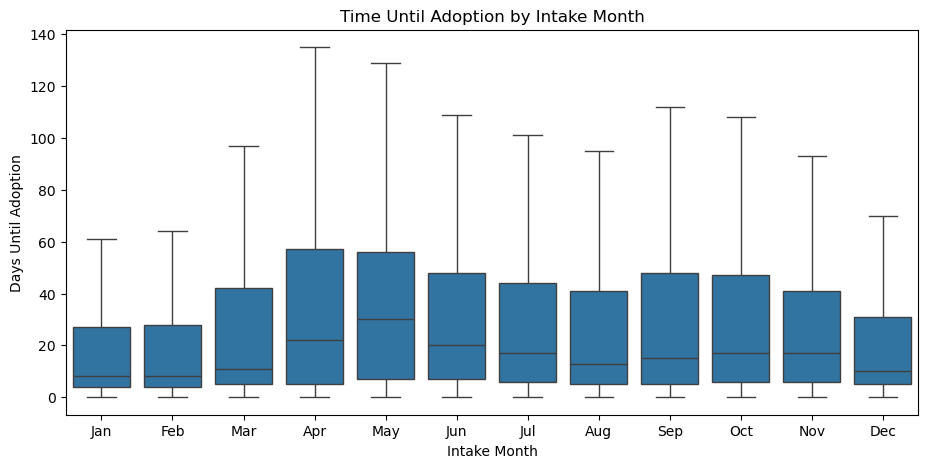

In [2792]:
# Display the disctribution of LOS by Intake Month
plt.figure(figsize=(11,5))

ax = sns.boxplot(
    data=shelter_data,
    x="intake_month",
    y=LOS,
    order=range(1,13),
    showfliers=False
)

ax.set_xticklabels([
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])

plt.xlabel("Intake Month")
plt.ylabel("Days Until Adoption")
plt.title("Time Until Adoption by Intake Month")

plt.show()

**Figure 9: Distribution of shelter length of stay by intake month.** The outliers were removed to improve visualization. Boxplot shows variation in shelter length of stay across intake months. Animals entering the shelter during spring generally exhibit longer median shelter stays than those entering during winter months, although the monthly distributions overlap substantially.

### Kruskal–Wallis test

To determine whether shelter length of stay differs across common cat breeds, a Kruskal–Wallis H test was performed. This nonparametric test compares the distributions of three or more independent groups without assuming normally distributed data.

**Hypotheses**

- **Null hypothesis ($H_0$):** The distribution of shelter length of stay is the same across all intake months.
- **Alternative hypothesis ($H_A$):** At least one intake month differs in its distribution of shelter length of stay.

In [2795]:
groups = [
    shelter_data.loc[shelter_data["intake_month"] == m, LOS]
    for m in range(1, 13)
]

H, p = kruskal(*groups)

print(f"H statistic: {H:.2f}")

if p < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p:.4f}")

H statistic: 1731.80
P-value: < 0.001


In [2796]:
N = len(shelter_data)
k = 12

epsilon_squared = (H - k + 1) / (N - k)

print(f"Epsilon² = {epsilon_squared:.4f}")

Epsilon² = 0.0265


**Interpretation**

A Kruskal–Wallis test indicated a statistically significant difference in adoption time across intake months (**H = 1731.80, p < 0.001**). However, the effect size was small (**ε² = 0.0265**), suggesting that although adoption time varies by intake month, the practical influence of seasonality is limited.

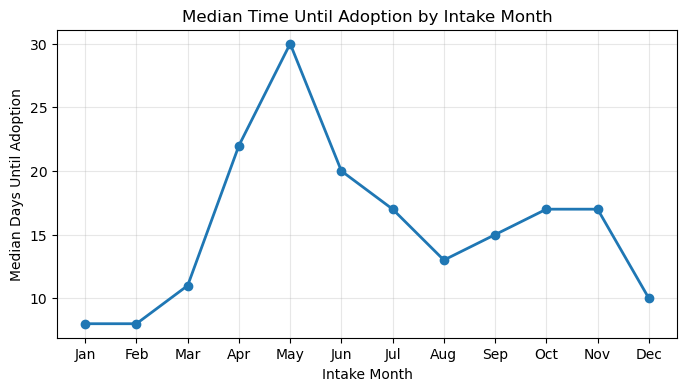

In [2798]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(8,4))
plt.plot(months, monthly_summary.values, marker="o", linewidth=2)

plt.xlabel("Intake Month")
plt.ylabel("Median Days Until Adoption")
plt.title("Median Time Until Adoption by Intake Month")
plt.grid(alpha=0.3)

plt.show()

**Figure 10. Median time until adoption by intake month.** Animals entering the shelter during spring, particularly in May, experienced the longest median adoption times, whereas those entering during winter months had the shortest median adoption times.

## Predictive Modeling

To evaluate whether animal characteristics could predict shelter length of stay, a multiple linear regression model was trained using animal type, breed group, and age group as predictor variables. Categorical variables were converted into dummy variables before fitting the model. The dataset was randomly divided into training (80%) and testing (20%) sets, and model performance was evaluated on the testing data.

In [2801]:
# Remove " Mix" from dog and cat breed names
shelter_data["breed_clean"] = shelter_data["breed"].str.replace(" Mix", "", regex=False)

# Count the number of animals in each breed separately for dogs and cats
breed_counts = (
    shelter_data.groupby(["animal_type", "breed_clean"])
      .size()
      .reset_index(name="count")
)

# Keep only breeds with at least 500 observations
common_breeds = breed_counts.loc[breed_counts["count"] >= 500,["animal_type", "breed_clean"]]

# Merge the common breed information back into the original dataset
shelter_data = shelter_data.merge(
    common_breeds.assign(common=True),
    on=["animal_type", "breed_clean"],
    how="left"
)

# Group uncommon breeds into "Other Dog Breed" and "Other Cat Breed"
shelter_data["breed_group"] = np.where(
    shelter_data["common"] == True,
    shelter_data["breed_clean"],
    np.where(
        shelter_data["animal_type"] == "Dog",
        "Other Dog Breed",
        "Other Cat Breed"
    )
)

# Remove helper column
shelter_data.drop(columns=["common"], inplace=True)

In [2802]:
# Remove observations with missing age group
data_ml = shelter_data.dropna(subset=["age_group"])

# Convert categorical predictors into dummy variables
X = pd.get_dummies(
    data_ml[["animal_type", "breed_group", "age_group", "intake_month"]],
    columns=["animal_type", "breed_group", "age_group", "intake_month"],
    drop_first=True
)

# Response variable (length of stay)
y = data_ml[LOS]

In [2803]:
# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [2804]:
# Create a multiple linear regression model
my_model = lm.LinearRegression()

In [2805]:
# Fit the model using the training data
my_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [2806]:
# Predict shelter length of stay for the testing data
predicted_los = my_model.predict(X_test)

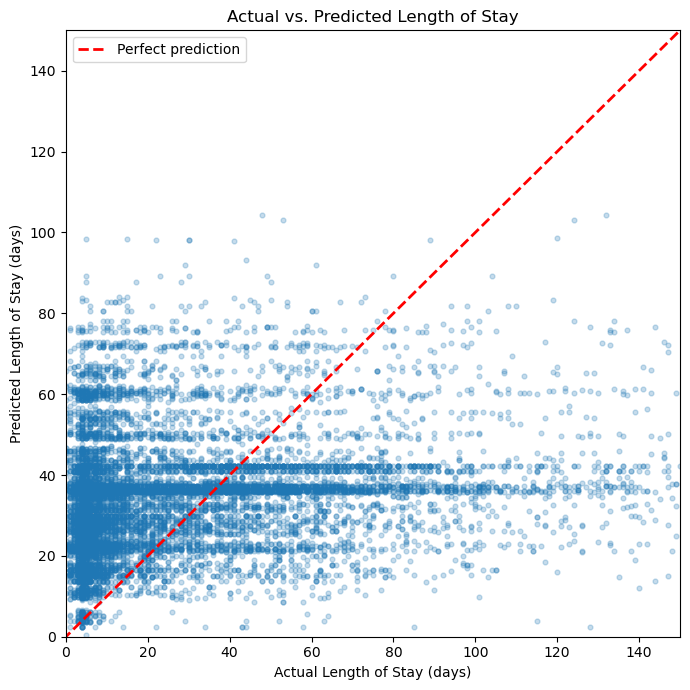

In [2807]:
# Plot actual versus predicted shelter length of stay
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predicted_los,
    alpha=0.25,
    s=12
)

# Perfect prediction line
min_val = min(y_test.min(), predicted_los.min())
max_val = max(y_test.max(), predicted_los.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Length of Stay (days)")
plt.ylabel("Predicted Length of Stay (days)")
plt.title("Actual vs. Predicted Length of Stay")
plt.legend()

plt.xlim(0, 150)
plt.ylim(0, 150)

plt.tight_layout()
plt.show()

**Figure 11. Actual versus predicted shelter length of stay for the multiple linear regression model.** x and y axes were limited to 0-150 to improvve visualization. The dashed reference line represents perfect predictions (y = x). Predictions are concentrated within a relatively narrow range because the regression model relies only on animal type, breed group, age group, and intake month. As a result, animals with the same characteristics receive similar predicted values even though their actual shelter lengths of stay may differ substantially.

In [2809]:
# Evaluate model performance
mae = mean_absolute_error(y_test, predicted_los)
rmse = np.sqrt(mean_squared_error(y_test, predicted_los))
r2 = r2_score(y_test, predicted_los)

print(f"MAE: {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R²: {r2:.3f}")

MAE: 30.95 days
RMSE: 60.95 days
R²: 0.054


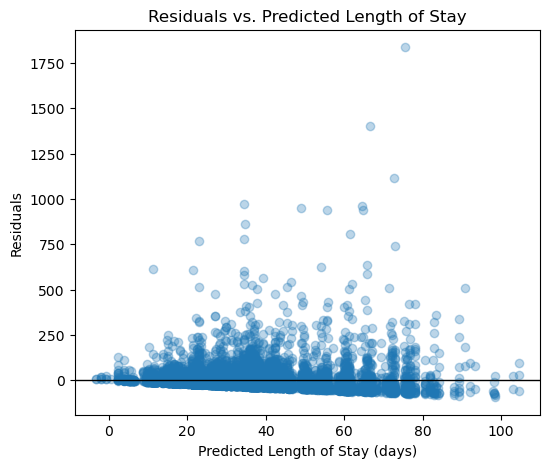

In [2810]:
# Calculate residuals
residuals = y_test - predicted_los

# Plot residuals against predicted values
plt.figure(figsize=(6,5))
plt.scatter(predicted_los, residuals, alpha=0.3)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Predicted Length of Stay (days)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Length of Stay")

plt.show()

**Figure 12. Residuals versus predicted shelter length of stay for the multiple linear regression model.** The residuals
are centered around zero with no clear systematic pattern, suggesting that the linear model does
not exhibit obvious bias. However, the wide spread of residuals and several large positive outliers
indicate substantial unexplained variability in shelter length of stay. These results are consistent
with the relatively low predictive performance of the model and suggest that important predictors
of adoption time are not captured by the available variables.

In [2812]:
# Create a function that predicts an animal's LOS based on the given factors
# intake_month should be provided as an integer from 1 (January) to 12 (December)
def predict_los(animal_type, breed_group, age_group, intake_month):
    # Valid categories
    valid_animal_types = shelter_data["animal_type"].unique()
    valid_breeds = shelter_data["breed_group"].unique()
    valid_age_groups = shelter_data["age_group"].dropna().unique()
    valid_months = sorted(shelter_data["intake_month"].unique())

    # Error checking
    if animal_type not in valid_animal_types:
        print(f"Error: '{animal_type}' is not a valid animal type.")
        print(f"Valid options: {sorted(valid_animal_types)}")
        return

    if breed_group not in valid_breeds:
        print(f"Error: '{breed_group}' is not a valid breed group.")
        print(f"Valid options: {sorted(valid_breeds)}")
        return

    if age_group not in valid_age_groups:
        print(f"Error: '{age_group}' is not a valid age group.")
        print(f"Valid options: {sorted(valid_age_groups)}")
        return

    if intake_month not in valid_months:
        print(f"Error: '{intake_month}' is not a valid intake month.")
        print(f"Valid options: {valid_months}")
        return

    # Create new observation
    new_animal = pd.DataFrame({
        "animal_type": [animal_type],
        "breed_group": [breed_group],
        "age_group": [age_group],
        "intake_month": [intake_month]
    })

    # Match training data
    new_animal = pd.get_dummies(new_animal)
    new_animal = new_animal.reindex(columns=X_train.columns, fill_value=0)

    # Predict
    prediction = my_model.predict(new_animal)[0]

    # Display result
    print("Prediction")
    print("-" * 40)
    print(f"Animal Type : {animal_type}")
    print(f"Breed       : {breed_group}")
    print(f"Age Group   : {age_group}")
    print(f"Intake Month: {intake_month}")
    print(f"Predicted Length of Stay: {prediction:.1f} days")

    if breed_group == "Other Dog Breed":
        print('Note: "Other Dog Breed" represents dog breeds with fewer than 500 observations.')
    elif breed_group == "Other Cat Breed":
        print('Note: "Other Cat Breed" represents cat breeds with fewer than 500 observations.')

    return prediction

In [2813]:
# Display example function executions
print("Example Predictions")
print("-------------------")

predict_los("Dog", "Pit Bull", "7+ years", 1)
predict_los("Cat", "Domestic Shorthair", "Under 6 months", 2)
predict_los("Dog", "Labrador Retriever", "Under 6 months", 5)
predict_los("Dog", "German Shepherd", "3–7 years", 7)
predict_los("Cat", "Siamese", "1–3 years", 10)
predict_los("Dog", "Other Dog Breed", "1–3 years", 12)

Example Predictions
-------------------
Prediction
----------------------------------------
Animal Type : Dog
Breed       : Pit Bull
Age Group   : 7+ years
Intake Month: 1
Predicted Length of Stay: 90.7 days
Prediction
----------------------------------------
Animal Type : Cat
Breed       : Domestic Shorthair
Age Group   : Under 6 months
Intake Month: 2
Predicted Length of Stay: 28.6 days
Prediction
----------------------------------------
Animal Type : Dog
Breed       : Labrador Retriever
Age Group   : Under 6 months
Intake Month: 5
Predicted Length of Stay: 17.6 days
Prediction
----------------------------------------
Animal Type : Dog
Breed       : German Shepherd
Age Group   : 3–7 years
Intake Month: 7
Predicted Length of Stay: 36.5 days
Prediction
----------------------------------------
Animal Type : Cat
Breed       : Siamese
Age Group   : 1–3 years
Intake Month: 10
Predicted Length of Stay: 33.5 days
Prediction
----------------------------------------
Animal Type : Dog
Breed    

np.float64(27.022097538062468)